# Feature Engineering for Developer Journey Analysis

This notebook builds the first behavioral feature layer for the project.

Our goal is to move from **raw activity logs** to **interpretable developer behavior signals**. Instead of treating all engagement as equally meaningful, we map activities into journey stages and engineer features that better reflect progression toward real product usage.

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect("Spring2026_IndustryProject/developer_project.duckdb")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

IOException: IO Error: Could not read from file "/Users/oliviachoi/Documents/GitHub/Spring2026_IndustryProject/developer_project.duckdb.tmp": Is a directory

## Step 1: Confirm the Activity Values

Before creating the ontology, we inspect the distinct activity values in the final cleaned table.

This helps us verify that:
- the activity labels are already clean enough to use directly
- we do not need an extra standardization layer
- the ontology can be built using the exact labels in `activity_final`

In [ ]:
con.execute("""
SELECT DISTINCT activity
FROM activity_final
ORDER BY activity
""").fetchdf()

,activity
0,brev
1,bugs filed
2,conf. sessions live
3,conference
4,contests
5,dev program membership
6,devzone downloads
7,dli training
8,event registrations
9,forum contributions


## Step 2: Create the Activity Ontology

We create an ontology that maps each activity to a **journey stage** and **effort level**.

This step is important because raw activity counts alone do not reflect developer maturity. For example:
- webinars and event registrations are early-stage signals
- downloads suggest evaluation behavior
- bugs filed and hackathons are stronger build-related signals

This mapping converts raw activity into behavior that can be used for segmentation.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE activity_ontology_v1 AS
SELECT * FROM (
    VALUES
    ('model api', 'Build', 'high'),
    ('dli training', 'Learn', 'medium'),
    ('contests', 'Champion', 'medium'),
    ('hackathons', 'Build', 'high'),
    ('on-demand views', 'Discover', 'low'),
    ('conference', 'Discover', 'low'),
    ('bugs filed', 'Build', 'high'),
    ('other events', 'Discover', 'low'),
    ('webinars', 'Discover', 'low'),
    ('dev program membership', 'Discover', 'low'),
    ('user feedback', 'Champion', 'medium'),
    ('program applications', 'Evaluate', 'medium'),
    ('devzone downloads', 'Evaluate', 'medium'),
    ('conf. sessions live', 'Discover', 'low'),
    ('forum contributions', 'Champion', 'high'),
    ('event registrations', 'Discover', 'low'),
    ('brev', 'Discover', 'low'),
    ('ngc downloads', 'Evaluate', 'medium'),
    ('product specific comms', 'Discover', 'low')
) AS t(activity, journey_stage, effort)
""")

## Step 3: Validate the Ontology Mapping

We validate the ontology by joining it back to `activity_final`.

This lets us confirm that:
- every activity in the final dataset is mapped
- there are no missing journey stages
- the activity distribution looks reasonable before feature engineering

In [ ]:
con.execute("""
SELECT 
    a.activity,
    o.journey_stage,
    COUNT(*) AS cnt
FROM activity_final a
LEFT JOIN activity_ontology_v1 o
    ON a.activity = o.activity
GROUP BY 1, 2
ORDER BY cnt DESC
""").fetchdf()

,activity,journey_stage,cnt
0,devzone downloads,Evaluate,39742594
1,ngc downloads,Evaluate,7720077
2,dev program membership,Discover,6767607
3,model api,Build,6466203
4,dli training,Learn,1934108
5,on-demand views,Discover,1440586
6,conf. sessions live,Discover,1312509
7,user feedback,Champion,1238576
8,forum contributions,Champion,784056
9,product specific comms,Discover,742452


## Step 4: Check the Activity Date Range

We inspect the date range in the final activity table before creating rolling-window features.

This matters because the dataset ends before today's date. If we used `CURRENT_DATE`, the 30-day window would not reflect the latest available activity in the dataset.

Instead, we anchor the window to the **maximum activity date in the data**.

In [ ]:
con.execute("""
SELECT 
    MIN(activity_date) AS min_date,
    MAX(activity_date) AS max_date
FROM activity_final
""").fetchdf()

,min_date,max_date
0,2020-01-01,2026-03-12


## Step 5: Inspect Raw Activity Volume

Before building features, we check which activities dominate the dataset.

This helps explain why raw counts alone are not enough. In this dataset, downloads and API-related events occur at extremely high volume, which can overpower more meaningful but less frequent behaviors.

In [ ]:
con.execute("""
SELECT 
    activity,
    COUNT(*) AS cnt
FROM activity_final
GROUP BY activity
ORDER BY cnt DESC
""").fetchdf()

,activity,cnt
0,devzone downloads,39742594
1,ngc downloads,7720077
2,dev program membership,6767607
3,model api,6466203
4,dli training,1934108
5,on-demand views,1440586
6,conf. sessions live,1312509
7,user feedback,1238576
8,forum contributions,784056
9,product specific comms,742452


## Step 6: Why We Use Log Scaling

The dataset is heavily skewed toward high-frequency events such as downloads and API usage.

If we used raw counts for all stages:
- high-volume activities would dominate the feature space
- many users would appear overly advanced
- the resulting segmentation would reflect event volume rather than true behavioral progression

To address this:
- we keep **raw counts** for lower-frequency early-stage behaviors like Discover and Learn
- we use **log-scaled scores** for Evaluate, Build, and Champion to reduce the effect of repeated machine-like or passive events

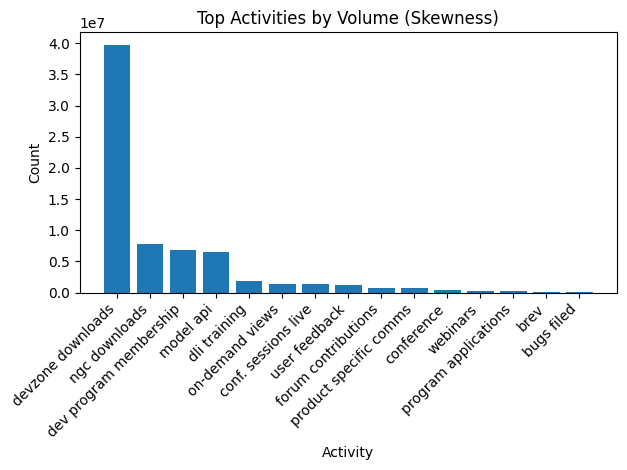

In [ ]:
activity_df = con.execute("""
SELECT activity, COUNT(*) as cnt
FROM activity_final
GROUP BY activity
ORDER BY cnt DESC
LIMIT 15
""").fetchdf()

plt.figure()
plt.bar(activity_df["activity"], activity_df["cnt"])
plt.xticks(rotation=45, ha='right')
plt.title("Top Activities by Volume (Skewness)")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
raw_vs_scaled = con.execute("""
SELECT 
    SUM(CASE WHEN o.journey_stage = 'Evaluate' THEN 1 ELSE 0 END) AS evaluate_count,
    LOG(1 + SUM(CASE WHEN o.journey_stage = 'Evaluate' THEN 1 ELSE 0 END)) AS evaluate_score
FROM activity_final a
JOIN activity_ontology_v1 o
    ON a.activity = o.activity
GROUP BY a.dev_contact
LIMIT 100000
""").fetchdf()

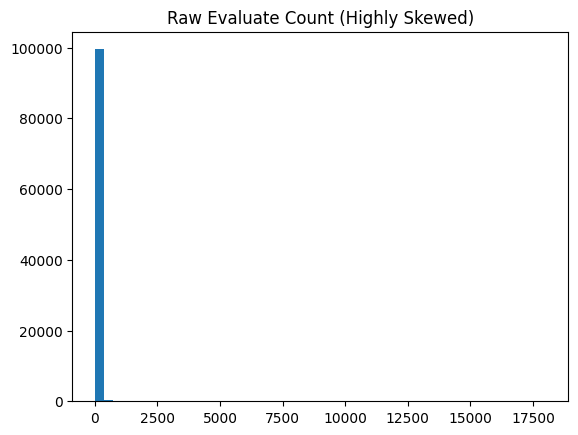

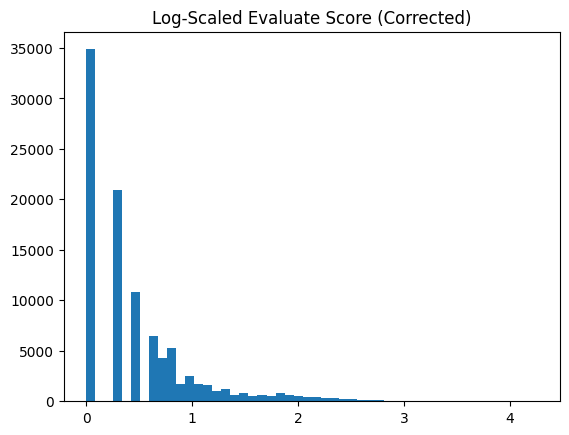

In [ ]:
plt.figure()
plt.hist(raw_vs_scaled["evaluate_count"], bins=50)
plt.title("Raw Evaluate Count (Highly Skewed)")
plt.show()

plt.figure()
plt.hist(raw_vs_scaled["evaluate_score"], bins=50)
plt.title("Log-Scaled Evaluate Score (Corrected)")
plt.show()

## Step 7: Create 30-Day Developer Features

We now aggregate activity into a **30-day feature window per developer**.

The table includes:
- raw stage counts for Discover and Learn
- log-scaled scores for Evaluate, Build, and Champion
- activity diversity
- recency relative to the latest date in the dataset

This creates a compact behavioral summary for each developer.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE dev_features_30d_v1 AS
WITH max_dt AS (
    SELECT MAX(activity_date) AS max_activity_date
    FROM activity_final
)
SELECT
    a.dev_contact AS developer_id,
    COUNT(*) AS total_activity,

    SUM(CASE WHEN o.journey_stage = 'Discover' THEN 1 ELSE 0 END) AS discover_count,
    SUM(CASE WHEN o.journey_stage = 'Learn' THEN 1 ELSE 0 END) AS learn_count,

    LOG(1 + SUM(CASE WHEN o.journey_stage = 'Evaluate' THEN 1 ELSE 0 END)) AS evaluate_score,
    LOG(1 + SUM(CASE WHEN o.journey_stage = 'Build' THEN 1 ELSE 0 END)) AS build_score,
    LOG(1 + SUM(CASE WHEN o.journey_stage = 'Champion' THEN 1 ELSE 0 END)) AS champion_score,

    COUNT(DISTINCT a.activity) AS activity_diversity,
    MAX(a.activity_date) AS last_activity_date,
    DATE_DIFF('day', MAX(a.activity_date), MAX(m.max_activity_date)) AS recency_days

FROM activity_final a
JOIN activity_ontology_v1 o
    ON a.activity = o.activity
CROSS JOIN max_dt m
WHERE a.activity_date >= m.max_activity_date - INTERVAL 30 DAY
GROUP BY a.dev_contact
""")

## Step 8: Preview the Feature Table

We inspect the first few rows of the new feature table to confirm the structure and verify that all expected fields were created correctly.

In [ ]:
con.execute("""
SELECT *
FROM dev_features_30d_v1
LIMIT 50
""").fetchdf()

,developer_id,total_activity,discover_count,learn_count,evaluate_score,build_score,champion_score,activity_diversity,last_activity_date,recency_days
0,7306481,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29
1,4864428,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29
2,10196302,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29
3,10196926,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29
4,5926018,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29
5,10198735,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29
6,10199161,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29
7,8501379,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29
8,10134689,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29
9,10196198,1,1.0,0.0,0.00000,0.0,0.0,1,2026-02-11,29


## Feature Distributions

We visualize the distribution of key features to ensure they are well-behaved.

After log scaling:
- most users should have low scores
- high values should be rare
- distributions should not be dominated by extreme outliers

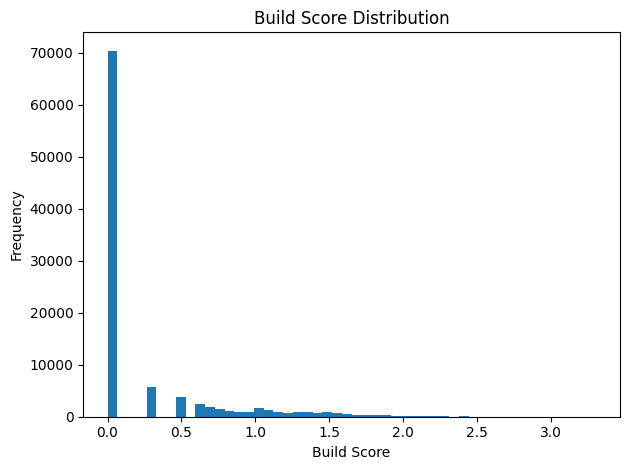

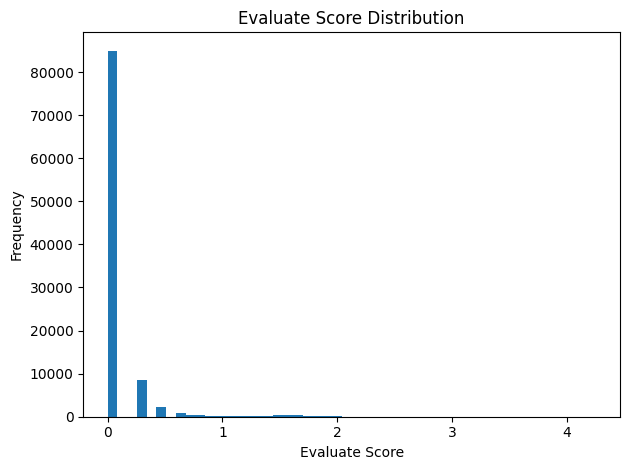

In [ ]:
feature_df = con.execute("""
SELECT build_score, evaluate_score, champion_score
FROM dev_features_30d_v1
LIMIT 100000
""").fetchdf()

plt.figure()
plt.hist(feature_df["build_score"], bins=50)
plt.title("Build Score Distribution")
plt.xlabel("Build Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(feature_df["evaluate_score"], bins=50)
plt.title("Evaluate Score Distribution")
plt.xlabel("Evaluate Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Step 9: Check Average Feature Values

We calculate average values across the feature table to understand the overall scale and distribution of the engineered signals.

This helps us verify whether:
- Discover is appropriately represented as top-of-funnel behavior
- Evaluate and Build are present but not dominating
- Champion remains rare, as expected

In [ ]:
con.execute("""
SELECT 
    AVG(build_score) AS avg_build_score,
    AVG(evaluate_score) AS avg_evaluate_score,
    AVG(champion_score) AS avg_champion_score,
    AVG(learn_count) AS avg_learn_count,
    AVG(discover_count) AS avg_discover_count
FROM dev_features_30d_v1
""").fetchdf()

,avg_build_score,avg_evaluate_score,avg_champion_score,avg_learn_count,avg_discover_count
0,0.259211,0.084559,0.002437,0.090077,0.819049


## Step 10: Define Journey State Rules

We use a rule-based approach to assign each developer a current journey state.

We choose rules instead of a model at this stage because they are:
- easy to interpret
- easy to explain to stakeholders
- useful as a baseline before clustering or HMM-based modeling

The journey states are:

- Dormant
- Discover
- Learn
- Evaluate
- Build

We do **not** include Champion as a main journey stage. Champion behaviors are better treated as a separate flag because advocacy can happen alongside other stages.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE dev_profile_v1 AS
SELECT
    *,
    CASE
        WHEN build_score > 1.2 THEN 'Build'
        WHEN evaluate_score > 0.25 THEN 'Evaluate'
        WHEN learn_count >= 1 THEN 'Learn'
        WHEN discover_count >= 1 THEN 'Discover'
        ELSE 'Dormant'
    END AS journey_state,
    CASE
        WHEN champion_score > 1.0 THEN 1
        ELSE 0
    END AS is_champion
FROM dev_features_30d_v1
""")

## Step 11: Inspect Journey State Distribution

We review the share of developers in each journey state.

This is a key validation step because the resulting distribution should resemble a realistic funnel:
- most users in Discover
- fewer in Learn and Evaluate
- a smaller set in Build
- some Dormant users

In [ ]:
con.execute("""
SELECT 
    journey_state,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS pct
FROM dev_profile_v1
GROUP BY 1
ORDER BY pct DESC
""").fetchdf()

,journey_state,pct
0,Discover,0.618858
1,Evaluate,0.149859
2,Dormant,0.091495
3,Build,0.075171
4,Learn,0.064617


## Step 12: Inspect Champion Behavior Separately

Champion behavior is modeled as a separate flag rather than a main stage.

This allows us to analyze advocacy and contribution independently from product progression. For example, a user may be in Build and also be a Champion.

In [ ]:
con.execute("""
SELECT
    AVG(is_champion) AS champion_rate
FROM dev_profile_v1
""").fetchdf()

,champion_rate
0,0.000292


In [ ]:
con.execute("""
SELECT
    journey_state,
    AVG(is_champion) AS champion_rate
FROM dev_profile_v1
GROUP BY 1
ORDER BY champion_rate DESC
""").fetchdf()

,journey_state,champion_rate
0,Dormant,0.001912
1,Evaluate,0.000654
2,Build,0.000093
3,Discover,0.000019
4,Learn,0.000000


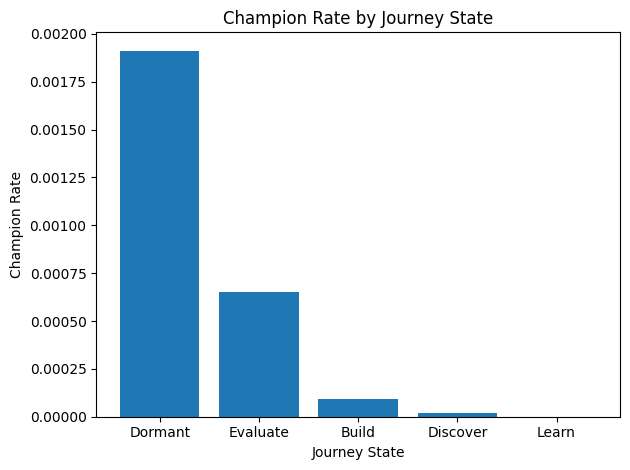

In [ ]:
champion_df = con.execute("""
SELECT journey_state, AVG(is_champion) as champion_rate
FROM dev_profile_v1
GROUP BY journey_state
ORDER BY champion_rate DESC
""").fetchdf()

plt.figure()
plt.bar(champion_df["journey_state"], champion_df["champion_rate"])
plt.title("Champion Rate by Journey State")
plt.xlabel("Journey State")
plt.ylabel("Champion Rate")
plt.tight_layout()
plt.show()

This gives us a strong baseline for the next phase of the project, which is to build:
- 90-day and 180-day feature tables
- transition analysis across windows
- clustering or sequence modeling on top of these engineered features

In [ ]:
con.close()